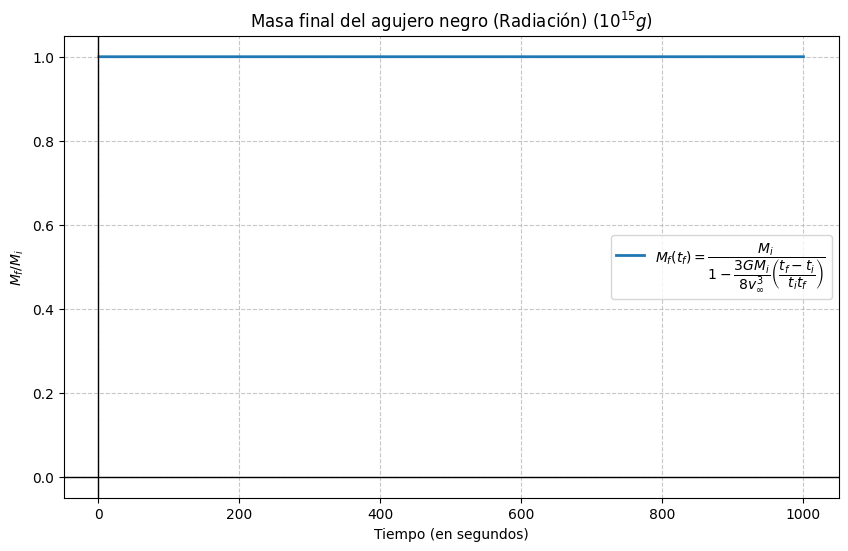

In [150]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el dominio (eje X)

G=6.674*10**-11 #N*m^2 /kg^2
Mi=1e15 #kg
Vi=1e3 #m/s
ti=1 #s
# np.linspace(inicio, fin, número_de_puntos)
t = np.linspace(ti, 1e3, 500)
k=(3*G*Mi)/(8*Vi**3)
p=1 - k * ( (1/ti) - (1/t) )
# 2. Definir la función (eje Y)
# Puedes cambiar esto por: x**2, np.exp(x), np.tan(x), etc.
M = np.divide(Mi, p, out=np.full_like(p, np.nan), where=p!=0)
etiqueta_ecuacion = r'$M_{f}(t_{f})=\dfrac{M_{i}}{1-\dfrac{3GM_{i}}{8v_{\infty}^{3}}\left(\dfrac{t_{f}-t_{i}}{t_{i}t_{f}} \right)}$'
# 3. Crear la figura y graficar
plt.figure(figsize=(10, 6))  # Tamaño de la figura en pulgadas
plt.plot(t, M/Mi, label=etiqueta_ecuacion, color='#1f77b4', linewidth=2)

# 4. Personalización (Estilo académico/científico)
plt.title('Masa final del agujero negro (Radiación) ($10^{15} g$)')
plt.xlabel('Tiempo (en segundos)')
plt.ylabel(r'$M_{f}/M_{i}$')

# Añadir ejes cruzados en el origen (0,0)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Añadir rejilla y leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("Radsin.pdf")
# 5. Mostrar el gráfico
plt.show()

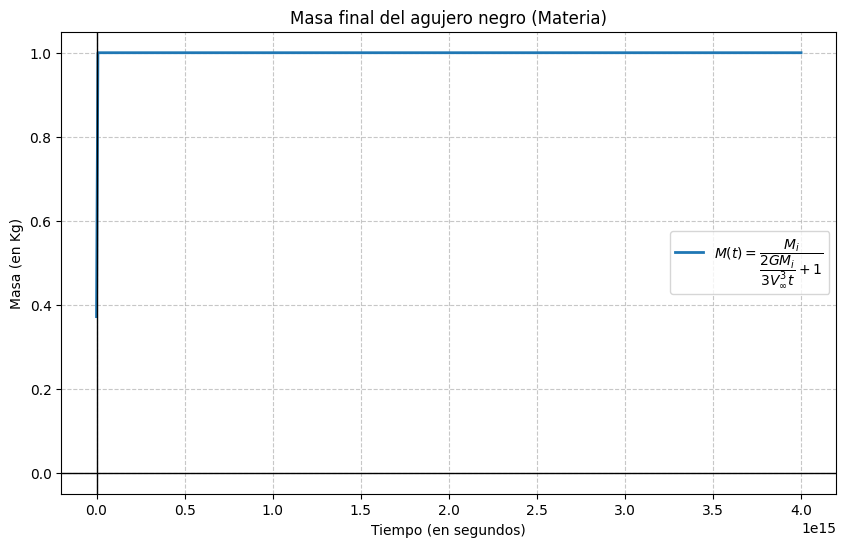

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#INCORRECTO
# 1. Definir el dominio (eje X)
# np.linspace(inicio, fin, número_de_puntos)
x = np.linspace(1, 4e15, 500)
G=6.674*10**-11 #N*m^2 /kg^2
Mi=20*1.9e30 #kg
Vi=1e7 #m/s
# 2. Definir la función (eje Y)
# Puedes cambiar esto por: x**2, np.exp(x), np.tan(x), etc.
y = Mi/(1+(2*G*Mi)/(3*Vi**3 *x)) 
etiqueta_ecuacion = r'$M(t) = \dfrac{M_{i}}{\dfrac{2GM_{i}}{3V_{\infty}^{3}t}+1}$'
# 3. Crear la figura y graficar
plt.figure(figsize=(10, 6))  # Tamaño de la figura en pulgadas
plt.plot(x, y/Mi, label=etiqueta_ecuacion, color='#1f77b4', linewidth=2)

# 4. Personalización (Estilo académico/científico)
plt.title('Masa final del agujero negro (Materia)')
plt.xlabel('Tiempo (en segundos)')
plt.ylabel('Masa (en Kg)')

# Añadir ejes cruzados en el origen (0,0)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Añadir rejilla y leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Mostrar el gráfico
plt.show()

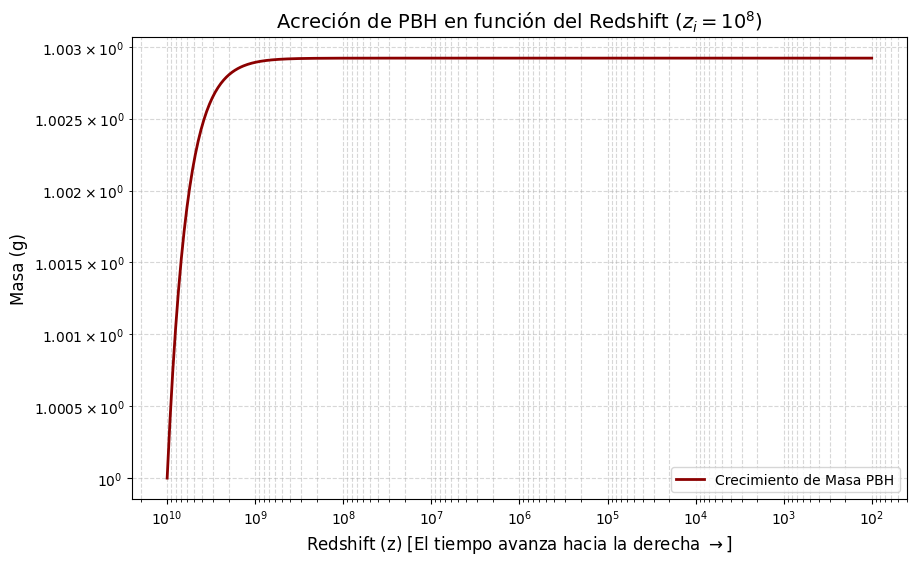

In [113]:
import numpy as np
import matplotlib.pyplot as plt
#Hecho con Gemini

# 1. Constantes Físicas (Unidades CGS para realismo o arbitrarias)
G = 6.674e-8        # cm^3 g^-1 s^-2
c = 2.998e10        # cm/s
M_sol = 1.989e33    # g
rho_r0 = 4.18e-34   # g/cm^3 (Densidad radiación actual aprox) - Ajustar según modelo

# Parámetros del Agujero Negro y el Medio
M_i = 20*1.9e33        # Masa inicial (g) - PBH típico
v_inf = c / 3       # Velocidad del sonido en era de radiación (c/sqrt(3))

# Redshift Inicial (Formación del PBH)
z_i = 1e10           # Muy temprano en el universo

# 2. Definir Constantes Agrupadas
# Constante C^2 derivada de la relación t-z
# C^2 = sqrt(32 pi G rho_r0 / 3)
C_sq = np.sqrt((32 * np.pi * G * rho_r0) / 3)

# Constante de Acreción K = 3 G M_i / 8 v_inf^3
K_acc = (3 * G * M_i) / (8 * v_inf**3)

# Factor total combinado para limpiar la fórmula
Factor = K_acc * C_sq

# 3. Dominio del Redshift
# Vamos desde z_i (pasado) hasta z_f (futuro, menor z)
# Usamos escala logarítmica porque el redshift abarca muchos órdenes de magnitud
z = np.geomspace(z_i, 100, 500) 

# 4. Ecuación M(z)
# El término es Factor * [ (1+zi)^2 - (1+z)^2 ]
denominador = 1 - Factor * ( (1+z_i)**2 - (1+z)**2 )

# Calcular masa protegiendo contra singularidades
M_z = np.divide(M_i, denominador, out=np.full_like(denominador, np.nan), where=denominador!=0)

# 5. Graficar
plt.figure(figsize=(10, 6))

# Nota: Invertimos el eje X para mostrar la flecha del tiempo (Pasado -> Futuro)
plt.plot(z, M_z/M_i, color='darkred', linewidth=2, label='Crecimiento de Masa PBH')

plt.xscale('log')
plt.yscale('log') # Escala logarítmica en Y también suele ser útil
plt.gca().invert_xaxis() # Invertir eje X: z alto (izquierda) -> z bajo (derecha)

plt.title(f'Acreción de PBH en función del Redshift ($z_i = 10^8$)', fontsize=14)
plt.xlabel('Redshift (z) [El tiempo avanza hacia la derecha $\\rightarrow$]', fontsize=12)
plt.ylabel('Masa (g)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.show()

C:\Users\jaosi\AppData\Local\Temp\ipykernel_32092\585699989.py:16: RuntimeWarning: overflow encountered in scalar power
  acrecion = (3 * G * M**2) / (8 * v_inf**3 * t**2)
C:\Users\jaosi\AppData\Local\Temp\ipykernel_32092\585699989.py:20: RuntimeWarning: overflow encountered in scalar power
  evaporacion = (hbar * c**4) / (3840 * np.pi * G**2 * M**2)


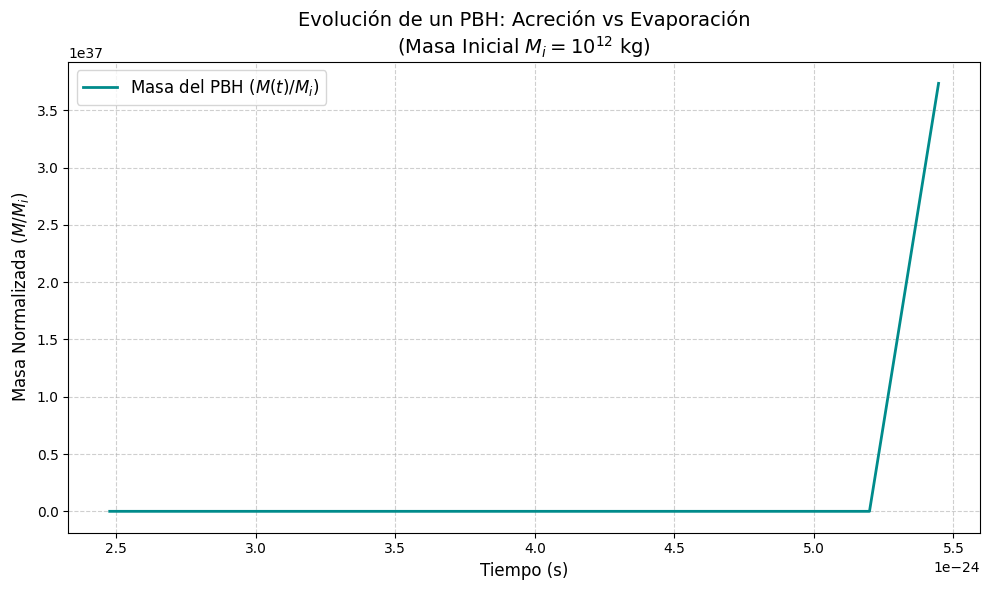

In [134]:
import numpy as np
import matplotlib.pyplot as plt
#Hecho por gemini

# 1. Definición de Constantes Físicas (Sistema Internacional - SI)
G = 6.67430e-11       # m^3 kg^-1 s^-2
c = 2.99792e8         # m/s
hbar = 1.05457e-34    # J s (o kg m^2 s^-1)
v_inf = c / np.sqrt(3)# Velocidad del sonido en era de radiación

# 2. Definición de la Ecuación Diferencial (0.5.17)
def dMdt(t, M):
    if M <= 0: return 0 
    
    # Término de Acreción (Ganancia) - Unidades resultantes: kg/s
    acrecion = (3 * G * M**2) / (8 * v_inf**3 * t**2)
    
    # Término de Evaporación (Pérdida Hawking) - Unidades resultantes: kg/s
    # Nota: El factor numérico 3840*pi*G^2 viene de la teoría estándar
    evaporacion = (hbar * c**4) / (3840 * np.pi * G**2 * M**2)
    
    return acrecion - evaporacion

# 3. Método Runge-Kutta de Orden 4 (RK4)
def runge_kutta_4(func, t0, M0, h, num_steps):
    t_values = np.zeros(num_steps)
    M_values = np.zeros(num_steps)
    
    t_values[0] = t0
    M_values[0] = M0
    
    t = t0
    M = M0
    
    for i in range(1, num_steps):
        if M <= 0:
            M_values[i:] = 0
            t_values[i:] = t + h * np.arange(num_steps - i)
            break
            
        k1 = h * func(t, M)
        k2 = h * func(t + 0.5 * h, M + 0.5 * k1)
        k3 = h * func(t + 0.5 * h, M + 0.5 * k2)
        k4 = h * func(t + h, M + k3)
        
        M = M + (k1 + 2*k2 + 2*k3 + k4) / 6.0
        t = t + h
        
        t_values[i] = t
        M_values[i] = M
        
    return t_values, M_values

# 4. Parámetros de Simulación (SI)
# Masa inicial crítica: 10^15 g equivale a 10^12 kg
M_i = 1e12  # kg

# Tiempo inicial estimado (formación del horizonte): t ~ GM/c^3
t_i = (G * M_i) / c**3 

# Configuración del tiempo de simulación
t_f = t_i * 1000  
num_steps = 10000
h = (t_f - t_i) / num_steps

# Ejecutar simulación
t_sol, M_sol = runge_kutta_4(dMdt, t_i, M_i, h, num_steps)

# 5. Gráfica
plt.figure(figsize=(10, 6))

# Graficamos masa normalizada (adimensional)
plt.plot(t_sol, M_sol / M_i, label='Masa del PBH ($M(t)/M_i$)', color='darkcyan', linewidth=2)

plt.title(f'Evolución de un PBH: Acreción vs Evaporación\n(Masa Inicial $M_i = 10^{{12}}$ kg)', fontsize=14)
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Masa Normalizada ($M/M_i$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Verificar tendencia final
cambio = M_sol[-1] - M_sol[0]
if cambio > 0:
    msg = f"Tendencia: Crecimiento neto (+{cambio:.2e} kg)"
else:
    msg = f"Tendencia: Pérdida neta ({cambio:.2e} kg)"

plt.text(0.6 * t_f, 0.5 * (np.max(M_sol/M_i) + np.min(M_sol/M_i)), 
         msg, fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

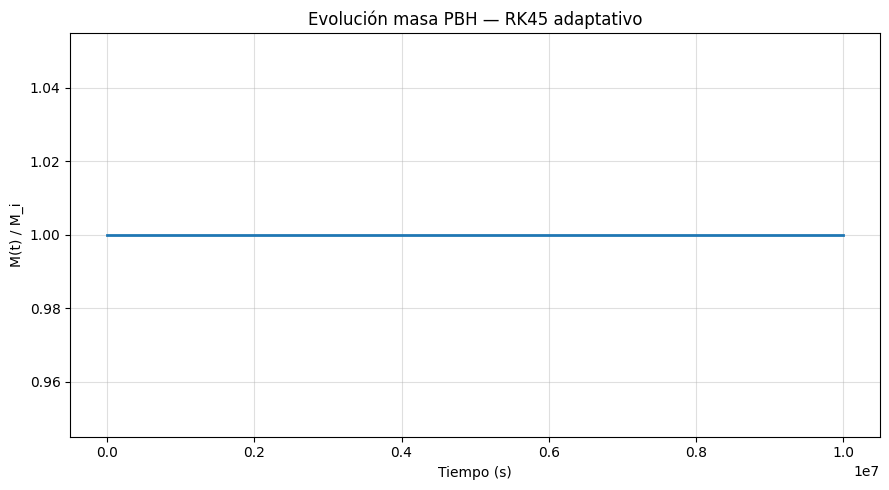

Integración exitosa: True
Mensaje solver: The solver successfully reached the end of the integration interval.
Masa inicial: 1000000000000000.0
Masa final: 1000000000000000.0
Cambio neto: 0.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#RK45
# ===============================
# Constantes físicas (SI)
# ===============================

G = 6.67430e-11
c = 2.99792e8
hbar = 1.05457e-34

v_inf = c / np.sqrt(3)

# ===============================
# Ecuación diferencial dM/dt
# ===============================

def dMdt(t, y):

    M = y[0]

    if M <= 0 or t <= 0:
        return [0]

    # Acreción radiación
    acrecion = (3 * G * M**2) / (8 * v_inf**3 * t**2)

    # Evaporación Hawking
    evaporacion = (hbar * c**4) / (3840 * np.pi * G**2 * M**2)

    return [acrecion - evaporacion]


# ===============================
# Condiciones iniciales
# ===============================

M_i = 1e15        # kg (PBH típico)
t_i = 1.0         # s (evitamos singularidad t=0)
t_f = 1e7         # s

# ===============================
# Integración RK45 adaptativa
# ===============================

sol = solve_ivp(
    dMdt,
    (t_i, t_f),
    [M_i],
    method='RK45',
    rtol=1e-8,
    atol=1e-12,
    max_step=1e4
)

# ===============================
# Extraer solución
# ===============================

t_sol = sol.t
M_sol = sol.y[0]

# ===============================
# Gráfica
# ===============================

plt.figure(figsize=(9,5))

plt.plot(t_sol, M_sol / M_i, linewidth=2)

plt.xlabel("Tiempo (s)")
plt.ylabel("M(t) / M_i")
plt.title("Evolución masa PBH — RK45 adaptativo")
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ===============================
# Diagnóstico
# ===============================

print("Integración exitosa:", sol.success)
print("Mensaje solver:", sol.message)
print("Masa inicial:", M_i)
print("Masa final:", M_sol[-1])
print("Cambio neto:", M_sol[-1] - M_i)
